In [43]:
#r "nuget: ScottPlot"
#r ".\task14\bin\Debug\net10.0\task14.dll"

using ScottPlot;
using System.Diagnostics;
using System.IO;
using task14;
using Microsoft.DotNet.Interactive.Formatting;

Formatter.Register(typeof(ScottPlot.Plot), (p, w) => w.Write(((ScottPlot.Plot)p).GetPngHtml(800, 600)), HtmlFormatter.MimeType);

Installed Packages ScottPlot, 5.1.59

In [44]:
double SolveSingleThread(double a, double b, Func<double, double> function, double step)
{
    double sum = 0.0;
    double current = a;
    
    while (current < b)
    {
        double next = current + step;
        if (next > b)
        {
            next = b;
        }

        sum += (function(current) + function(next)) / 2.0 * (next - current);
        current = next;
    }

    return sum;
}


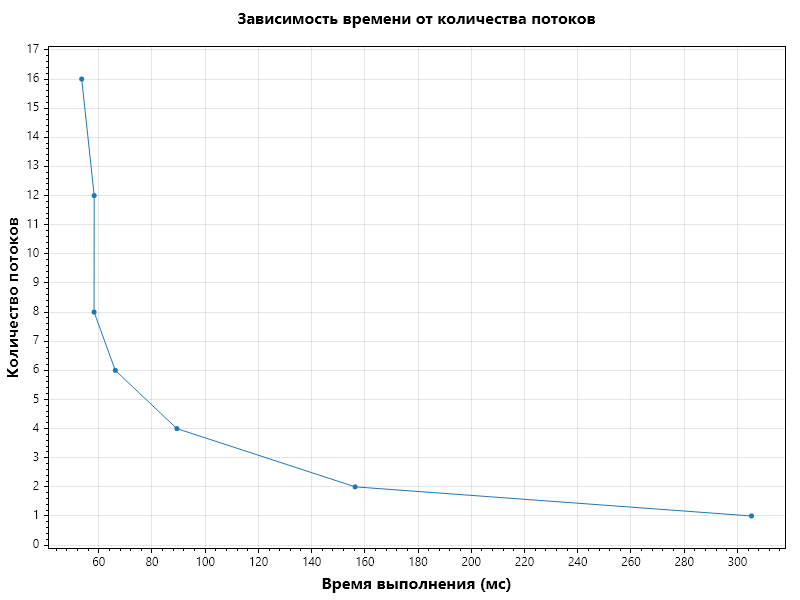

In [ ]:
Func<double, double> func = x => Math.Sin(x);
double a = -100.0;
double b = 100.0;
        
double bestStep = 1e-5;  // Захардкодил, ибо в противном случае почему-то происходит деградация

int[] threads = { 1, 2, 4, 6, 8, 12, 16 };
double[] xs = new double[threads.Length];
double[] ys = new double[threads.Length];

double minTime = double.MaxValue;
int bestThreads = 1;

for (int i = 0; i < threads.Length; i++)
{
    int tc = threads[i];
    double totalTime = 0;

    for (int j = 0; j < 3; j++) 
    {
        Stopwatch sw = Stopwatch.StartNew();
        DefiniteIntegral.Solve(a, b, func, bestStep, tc);
        sw.Stop();
        totalTime += sw.Elapsed.TotalMilliseconds; 
    }

    double avgTime = totalTime / 3.0;
    
    xs[i] = avgTime; 
    ys[i] = tc;

    if (avgTime < minTime)
    {
        minTime = avgTime;
        bestThreads = tc;
    }
}

// Тут отчет для txt
double singleTotal = 0;
for (int j = 0; j < 3; j++)
{
    Stopwatch sw = Stopwatch.StartNew();
    SolveSingleThread(a, b, func, bestStep);
    sw.Stop();
    singleTotal += sw.Elapsed.TotalMilliseconds;
}
double singleAvg = singleTotal / 3.0;

double diff = singleAvg - minTime;
double percent = (diff / singleAvg) * 100.0;

using (StreamWriter writer = new StreamWriter("report.txt"))
{
    writer.WriteLine($"Оптимальный шаг: {bestStep}");
    writer.WriteLine($"Оптимальное количество потоков: {bestThreads}");
    writer.WriteLine($"Время многопоточной версии: {minTime:F2} мс");
    writer.WriteLine($"Время однопоточной версии: {singleAvg:F2} мс");
    writer.WriteLine($"Ускорение: на {percent:F2}% быстрее");
}

Plot myPlot = new Plot();
myPlot.Add.Scatter(xs, ys);

myPlot.XLabel("Время выполнения (мс)");
myPlot.YLabel("Количество потоков");
myPlot.Title("Зависимость времени от количества потоков");

myPlot